In [1]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))


/home/gtamo/MS_ML


In [2]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats

# user defined modules
import Rdkit_tools as rdkit_tools
# importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
# from tdc.multi_pred import DTI

> could not load openbabel


In [3]:
## params
active_c = '#008bfb' # "#3B85C1"
silent_c = '#ff0051'

RAW_PROTEOMICS_PATH   = 'data/MS/20260424_Proteomics_Database_CSV_Export.csv'
CLEAN_PROTEOMICS_PATH = 'data/MS/CDD CSV Export - 2026-04-29 06h13m33s.csv'
CHEMLIB_PATH          = 'data/chemical_libs/20260430_SERAC_lib.csv' # smiles + compound
OT_ROOT               = 'data/external/opentarget'
OT_CACHE              = 'output/MS/opentargets_target_disease.parquet'
GENE_SAR_OUT          = 'output/MS/20260505_geneSAR_R2_ctf0.4.csv' # R2 per gene
MCS_CSV               = 'output/MS/20260505_target_final_mcs.csv' # MCS enrichment

## 0. Imports

In [4]:
%%time
## raw proteomics data
df_raw   = pd.read_csv(RAW_PROTEOMICS_PATH)
## compounds ids and smiles
serac_df = (pd.read_csv(CHEMLIB_PATH)
            .drop(['CDD Number','Synonyms'],axis=1)
            .rename(columns={'Molecule Name':'compound','SMILES':'smiles','Projects':'project'})
            .drop('project',axis=1)
            .drop_duplicates())

## Get clean MS data to get plate Ids
MS = pd.read_csv(CLEAN_PROTEOMICS_PATH).drop(['CDD Number'],axis=1)
MS = MS[MS['MSData - Proteomics activities: Source']=='SERAC'] # 
MS['MSData - Proteomics activities: Date'] = pd.to_datetime(MS['MSData - Proteomics activities: Date'])
MS['MSData - Proteomics activities: MSPlate'].unique()

# remove plate 12 data (from Daniela)
# MS = MS[~MS['MSData - Proteomics activities: MSPlate'].isin(['Pw33','Plate12']) ]

# if a compound is tested multiple times, get only by latest date
MS = MS.sort_values('MSData - Proteomics activities: Date',ascending=False).reset_index()
MS = MS.groupby('Molecule Name').first().reset_index()

print('>', len(MS['Molecule Name'].unique()),'unique compounds')
print('> Ligase(s)',list(MS['MSData - Proteomics activities: Ligase'].unique()))
print('> Cellline',list(MS['MSData - Proteomics activities: Cell line'].unique()))
print('> dim:',MS.shape)
MS.head(1)


> 1617 unique compounds
> Ligase(s) ['FBXO31']
> Cellline ['HepG2']
> dim: (1617, 31)
CPU times: user 30.3 s, sys: 9.17 s, total: 39.5 s
Wall time: 39.6 s


,Molecule Name,index,SMILES,Molecular weight (g/mol),log P,Topological polar surface area (Å²),Synonyms,Subseries,PROTAC Target,PROTAC Parent,...,MSData - Proteomics activities: Cell line,MSData - Proteomics activities: Sample Condition,MSData - Proteomics activities: Incubation time (h),MSData - Proteomics activities: Concentration (uM),MSData - Proteomics activities: MSPlate,MSData - Proteomics activities: Screen,MSData - Proteomics activities: Nr. Down,MSData - Proteomics activities: Cmpd Activity,MSData - Proteomics activities: Genes Down,MSData - Proteomics activities: Date
0,SRB-0000385,1316,O=C(OCC1C2=CC=CC=C2C2=CC=CC=C12)N1[C@H]2CC3=CC...,410.473,4.2,58.6,NaN,AJ,NaN,NaN,...,HepG2,WildType,24.0,10.0,Pw79,1.0,3.0,Low (2-10),MPZL3;TMEM39B;SUFU,2026-04-15


In [5]:
%%time
## Clean, filter and format raw MS data
# df_raw = df_raw[~df_raw['MSPlate'].isin(['Pw33','Plate12']) ]
df_raw = df_raw[df_raw['MoleculeBatchID'].isin(MS['MSData - Proteomics activities: Molecule-Batch ID'])]
parts = df_raw['MoleculeBatchID'].str.split('-', n=2, expand=True)
df_raw['compound'] = parts[0] + '-' + parts[1]   # 'SRB-0000385'
df_raw['batch']    = parts[2]                    # '001'
df_raw.head(2)

CPU times: user 19 s, sys: 6.82 s, total: 25.8 s
Wall time: 25.8 s


,MoleculeBatchID,MSPlate,genes,pg,logfc,pvalue,adjpval,significant,uniquecontrast,compound,batch
0,SRB-0001703-001,Plate1,MMAB,Q96EY8,-0.010119,0.923509,0.995746,0.0,X1703.001_vs_DMSO_Plate1,SRB-0001703,001
1,SRB-0001703-001,Plate1,ETFB,P38117,0.077234,0.465782,0.919269,0.0,X1703.001_vs_DMSO_Plate1,SRB-0001703,001


In [6]:
%%time
## Get smiles from library and compute MF features
serac_df = serac_df.dropna().reset_index(drop=True)
failed_CMs = rdkit_tools.check_smiles_RDKiT(serac_df)
serac_df = serac_df[~serac_df['compound'].isin(serac_df)]
## then compute features:
properties  = rdkit_tools.compute_properties_from_smiles(serac_df)
MF          = rdkit_tools.get_MF_bits_from_df(serac_df,nBits=2048)
MF_features = pd.merge(MF,properties)
MF_features.head(1)

100%|██████████| 10047/10047 [00:04<00:00, 2381.53it/s]


CPU times: user 17.6 s, sys: 62.8 ms, total: 17.6 s
Wall time: 17.6 s


,compound,F0,F1,F2,F3,F4,F5,F6,F7,F8,...,F2044,F2045,F2046,F2047,Hba,Hbd,MW,TPSA,LogP,NRB
0,SRB-0010059,0,1,0,0,0,0,0,0,1,...,0,0,0,0,12.0,7.0,995.454139,283.36,0.6925,24.0


## 1. Plate bias - variance analysis

> 163 compounds present on ≥2 plates  (428 (compound, plate) rows)

> per-plate disagreement vs cross-plate consensus (noisy = high mean_abs_dev; biased = large |bias|) :
                n_compounds_shared  mean_abs_dev  median_abs_dev   bias
MSPlate                                                                
Plate12                         13         0.235           0.183 -0.211
Plate23                         11         0.211           0.048 -0.158
Plate2                           5         0.201           0.128  0.108
Plate15                         22         0.195           0.136  0.028
Plate38                          5         0.123           0.119  0.123
Plate6                           9         0.091           0.108  0.015
Plate19                         13         0.091           0.069  0.082
Plate8                          11         0.089           0.034  0.068
Plate14                          3         0.085           0.047 -0.053
Plate1                          12   

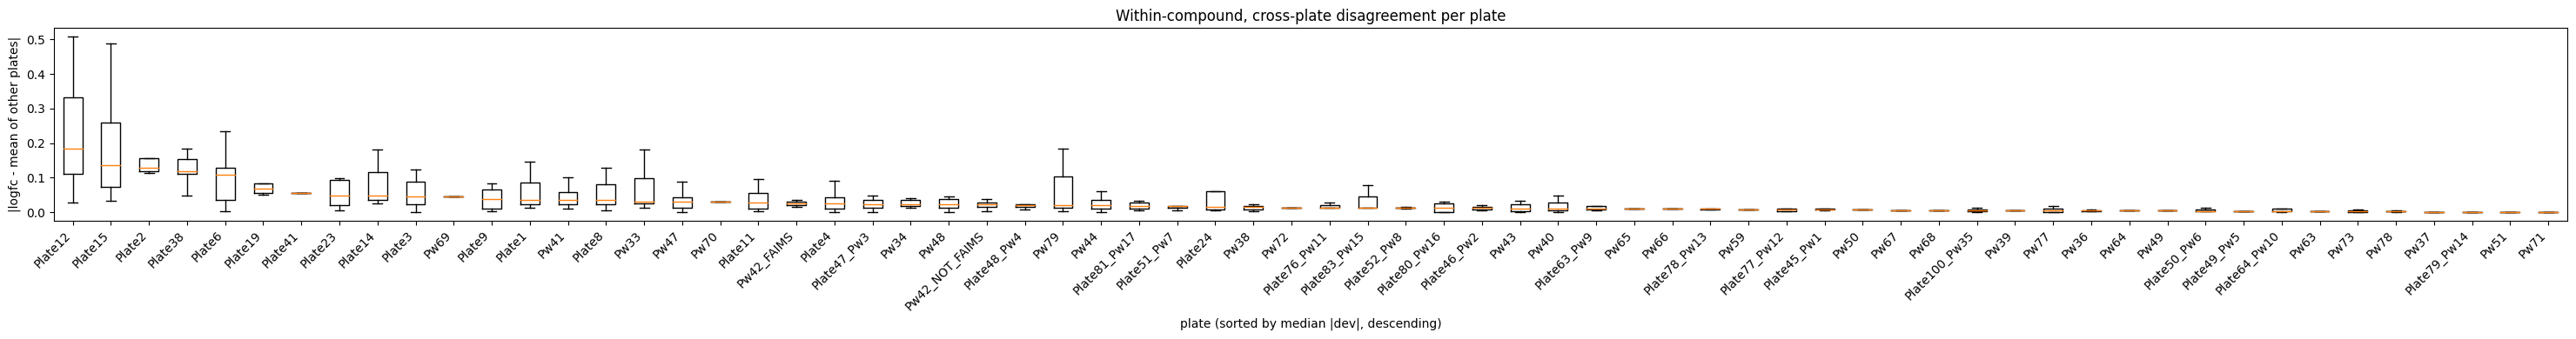

In [7]:
# checking within-compound - cross plate variance:
## For each compound measured on ≥2 plates, compute the deviation of each
## (compound, plate) measurement from the mean over the OTHER plates of the
## same compound. Per-plate summaries:
##   - mean_abs_dev / median_abs_dev : how far the plate's measurements sit from the cross-plate consensus
##   - bias                          : signed mean deviation — catches a plate that's systematically high/low
##   - n_compounds_shared            : compounds shared with at least one other plate
## Noisy plate = high mean_abs_dev; biased plate = large |bias|.
## Set GENE_FILTER to restrict to one target; None uses all genes (more robust signal).

PLATE_COL   = 'MSPlate'
GENE_FILTER = None # 'KDM1B'       # e.g. 

src = df_raw if GENE_FILTER is None else df_raw[df_raw['genes'] == GENE_FILTER]

# 1) per (compound, plate) mean logfc — collapse intra-plate replicates
cp = (src.groupby(['compound', PLATE_COL])['logfc']
         .mean()
         .reset_index())

# 2) keep compounds present on ≥2 plates (otherwise no cross-plate comparison)
n_plates_per_cmp = cp.groupby('compound')[PLATE_COL].nunique()
multi = n_plates_per_cmp[n_plates_per_cmp >= 2].index
cp = cp[cp['compound'].isin(multi)].copy()
print(f'> {len(multi):,} compounds present on ≥2 plates  '
      f'({len(cp):,} (compound, plate) rows)')

# 3) leave-one-out mean: compare each (cmp, plate) to mean of OTHER plates of the same cmp
g = cp.groupby('compound')['logfc']
cp['_n']      = g.transform('size')
cp['_others'] = (g.transform('sum') - cp['logfc']) / (cp['_n'] - 1)
cp['dev']     = cp['logfc'] - cp['_others']
cp['abs_dev'] = cp['dev'].abs()

# 4) aggregate per plate
plate_summary = (cp.groupby(PLATE_COL)
                   .agg(n_compounds_shared = ('compound', 'nunique'),
                        mean_abs_dev       = ('abs_dev', 'mean'),
                        median_abs_dev     = ('abs_dev', 'median'),
                        bias               = ('dev',     'mean'))
                   .sort_values('mean_abs_dev', ascending=False))

header = ('per-plate disagreement vs cross-plate consensus '
          '(noisy = high mean_abs_dev; biased = large |bias|)')
print('\n>', header, ':')
print(plate_summary.round(3).to_string())

# 5) quick visualisation — boxplot of |deviation| per plate, ordered by median
plate_order = (cp.groupby(PLATE_COL)['abs_dev'].median()
                 .sort_values(ascending=False).index.tolist())
fig, ax = plt.subplots(figsize=(max(6, 0.45 * len(plate_order)), 4))
data = [cp.loc[cp[PLATE_COL] == p, 'abs_dev'].values for p in plate_order]
ax.boxplot(data, labels=plate_order, showfliers=False)
ax.set_ylabel('|logfc - mean of other plates|')
suffix = f' — {GENE_FILTER}' if GENE_FILTER else ''
ax.set_xlabel(f'plate (sorted by median |dev|, descending){suffix}')
ax.set_title('Within-compound, cross-plate disagreement per plate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 2. ML prediction for single gene

In [ ]:
## correct bias + drop noisy plates — idempotent.
## On first run we snapshot df_raw, so subsequent re-runs (with a different
## NOISY_PLATES) always restore the full data before filtering. If you re-load
## df_raw upstream, flip RESET_SNAPSHOT=True once to refresh.

RESET_SNAPSHOT = False
if RESET_SNAPSHOT or '_df_raw_pristine' not in globals():
    _df_raw_pristine = df_raw.copy()
    print(f'> snapshotted df_raw at {len(_df_raw_pristine):,} rows '
          f'over {_df_raw_pristine["MSPlate"].nunique():,} plates')
df_raw = _df_raw_pristine.copy()      # always start from the pristine snapshot

# bias correction
plate_bias = cp.groupby('MSPlate')['dev'].mean()
df_raw['logfc_corrected'] = df_raw['logfc']#  - df_raw['MSPlate'].map(plate_bias).fillna(0)

# drop the entire Plate{N} cohort — LOPO showed those plates have a compressed
# dynamic range for KDM1B (std_y ~0.1, R² strongly negative), while the Pw* and
# Plate*_Pw* hybrid plates carry the actual SAR signal.
import re
# NOISY_PLATES = sorted(p for p in df_raw['MSPlate'].dropna().unique()
#                       if re.match(r'^Plate\d+$', str(p)))
NOISY_PLATES = ['Plate12','Pw33'] # ,'Plate8','Plate15' 
print(f'> {len(NOISY_PLATES)} Plate{{N}} plates flagged for drop: {NOISY_PLATES}')
n_before = len(df_raw)
df_raw = df_raw[~df_raw['MSPlate'].isin(NOISY_PLATES)].copy()
print(f'> dropped {n_before - len(df_raw):,} rows from noisy plates {NOISY_PLATES}')
print(f'> df_raw: {len(df_raw):,} rows over {df_raw["MSPlate"].nunique():,} plates remaining')


In [ ]:
gene = 'ARG1' # 'ANXA13' # 'KDM1B' # 'CELF2' # 'TRAIP' #  'UNC45A' # 'TUBB8' # 'DCDC2' # 'SIL1' #  'ACADVL' #   'SQSTM1' # 'YARS1' #      
tardf = df_raw[df_raw['genes']==gene]

tardf_ml       = tardf.groupby('compound')['logfc_corrected'].mean().reset_index()
tardf_ml['label'] = tardf_ml['logfc_corrected']

ML_data = pd.merge(MF_features, tardf_ml[['compound','label']], on='compound').dropna()
print(ML_data.shape)
ML_data.head(2)


In [ ]:
%%time
# params_xgb = {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0, 'min_child_weight': 1}
params_rf = {'n_estimators':100,'max_depth':20,'max_features':'sqrt','min_samples_leaf':1}
# model = XGBRegressor(**params_xgb, n_jobs=-1, random_state=0)
model = RandomForestRegressor(**params_rf, n_jobs=8, random_state=0)
trained_model, df_pred =  ML_Reg.run_K_Fold_Xval_Regression(ML_data, model=model,col_to_rm=['compound','label'], ID='compound', get_ints=False, v=True,to_impute=None,rm_empty_cols=False)

In [ ]:
# model = RandomForestClassifier(n_estimators=100,n_jobs=-1,random_state=0) # 
ML_data['label'] = (ML_data['label'] < -1.0) * 1
baseline = ML_data['label'].sum() / ML_data.shape[0]

stats_tools.check_ML_data(ML_data)

params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'scale_pos_weight': 1}
model = XGBClassifier(**params,n_jobs=-1,random_state=42)
trained_model, df_pred =  ML_Class.run_K_Fold_Xval_Classification(ML_data, ID='compound', model=model,
                                   folds=5, col_to_rm=['compound','label'], v=True, ctf=0.5, impute_by_mean=False)


In [ ]:
roc_df = ML_Class.plot_roc_curve(
    [df_pred],
    c=[active_c],
    l=['XGB'],
    metric2show=['roc_auc'],dpi=70,legend=True
)

In [ ]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(df_pred, npts=30, plot=True,baseline=baseline,dpi=80)

In [ ]:
## A/B/C/D matrix — isolate the contribution of bias correction and plate drops.
## Same K-fold split (random_state=SEED), same RF hyperparams; only the label
## column and the plate-drop list change. Reads from the pristine snapshot so
## the comparison isn't biased by whatever filter is currently applied to df_raw.

GENE  = 'CELF2'
SEED  = 0

# pristine view + correction
_pdf = _df_raw_pristine.copy()
_pdf['logfc_corrected'] = _pdf['logfc'] - _pdf['MSPlate'].map(plate_bias).fillna(0)

rows = []
for label_col in ['logfc', 'logfc_corrected']:
    for drop in [[], NOISY_PLATES]:
        sub = _pdf[(_pdf['genes'] == GENE) & ~_pdf['MSPlate'].isin(drop)]
        ml  = (sub.groupby('compound')[label_col].mean()
                  .reset_index()
                  .rename(columns={label_col: 'label'}))
        ml  = pd.merge(MF_features, ml, on='compound').dropna()
        if len(ml) < 5:
            rows.append({'label': label_col, 'drop_plates': bool(drop),
                         'n_compounds': len(ml), 'r2': float('nan')})
            continue
        rf = RandomForestRegressor(**params_rf, n_jobs=8, random_state=SEED)
        _, df_pred = ML_Reg.run_K_Fold_Xval_Regression(
            ml, model=rf, col_to_rm=['compound', 'label'], ID='compound',
            get_ints=False, v=False, to_impute=None, rm_empty_cols=False,
        )
        r2 = ML_Reg.get_reg_metrics_from_preddf(df_pred, v=False)['r2']
        rows.append({'label': label_col, 'drop_plates': bool(drop),
                     'n_compounds': len(ml), 'r2': r2})

abcd = pd.DataFrame(rows)
print(f'> A/B/C/D matrix for gene={GENE}, 5-fold CV, seed={SEED}')
print(abcd.round(3).to_string(index=False))
print('\n  baseline (no correction, no drop)  vs  full (corrected + dropped):')
baseline = abcd.query("label == 'logfc' and not drop_plates")['r2'].iloc[0]
full     = abcd.query("label == 'logfc_corrected' and drop_plates")['r2'].iloc[0]
print(f'  Δ R² = {full - baseline:+.3f}   '
      f'(baseline={baseline:.3f}, full={full:.3f})')


In [ ]:
## Leave-one-plate-out cross-validation (LOPO).
## For each plate P:
##   • train = compounds tested on plates ≠ P, mean logfc_corrected
##   • test  = compounds tested on plate P,  using their plate-P logfc_corrected
## Per-plate R² (sklearn coefficient of determination, can go negative) tells you
## whether the rest of the data can predict THIS plate's measurements.
## Negative or near-zero R² → plate is divergent (noise or distinct chemotype);
## high R² → plate is consistent with the rest. Compounds may overlap between
## train (their non-P data) and test (their P data); that's intentional — we're
## asking "is plate P's logfc reading consistent with the SAR seen elsewhere?".

from sklearn.metrics import r2_score as _sk_r2
GENE      = 'UNC45A'
LABEL_COL = 'logfc_corrected'
MIN_TEST  = 5         # skip plates with too few compounds to score reliably
MIN_TRAIN = 20

# again, work off the pristine snapshot so a previous drop doesn't pre-filter the LOPO
_g = _df_raw_pristine.copy()
_g['logfc_corrected'] = _g['logfc'] - _g['MSPlate'].map(plate_bias).fillna(0)
_g = _g[(_g['genes'] == GENE) & _g['MSPlate'].notna()]

rows = []
_plates = sorted(_g['MSPlate'].unique())
for held in tqdm(_plates, desc=f'LOPO {GENE}'):
    tr = _g[_g['MSPlate'] != held].groupby('compound')[LABEL_COL].mean().reset_index()
    te = _g[_g['MSPlate'] == held].groupby('compound')[LABEL_COL].mean().reset_index()
    tr = tr.rename(columns={LABEL_COL: 'label'})
    te = te.rename(columns={LABEL_COL: 'label'})

    tr_xy = pd.merge(MF_features, tr, on='compound').dropna()
    te_xy = pd.merge(MF_features, te, on='compound').dropna()
    if len(te_xy) < MIN_TEST or len(tr_xy) < MIN_TRAIN:
        continue

    rf = RandomForestRegressor(**params_rf, n_jobs=8, random_state=0)
    rf.fit(tr_xy.drop(columns=['compound', 'label']), tr_xy['label'])
    yhat = rf.predict(te_xy.drop(columns=['compound', 'label']))
    yte  = te_xy['label'].values

    rows.append({
        'plate':    held,
        'n_train':  len(tr_xy),
        'n_test':   len(te_xy),
        'r2_lopo':  _sk_r2(yte, yhat) if len(yte) >= 2 else float('nan'),
        'pearson':  np.corrcoef(yte, yhat)[0, 1] if len(yte) >= 2 else float('nan'),
        'rmse':     np.sqrt(((yte - yhat) ** 2).mean()),
        'mean_y':   yte.mean(),
        'std_y':    yte.std(),
    })

lopo_df = pd.DataFrame(rows).sort_values('r2_lopo', ascending=True)
print(f'> LOPO for gene={GENE}, label={LABEL_COL}, RF seed=0')
print(lopo_df.round(3).to_string(index=False))

# bar chart — red bars are plates the model can't predict (R² < 0)
fig, ax = plt.subplots(figsize=(max(6, 0.32 * len(lopo_df)), 4))
colors = ['crimson' if r < 0 else '#3182bd' for r in lopo_df['r2_lopo']]
ax.bar(range(len(lopo_df)), lopo_df['r2_lopo'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(lopo_df)))
ax.set_xticklabels(lopo_df['plate'], rotation=45, ha='right')
ax.set_ylabel('LOPO R² (sklearn r2_score)')
ax.set_title(f'Leave-one-plate-out predictability — {GENE}  (red = R² < 0)')
plt.tight_layout()
plt.show()


## 3. ML prediction for multiple gene

In [ ]:
genes_highlighted = [
    'AARS1', 'ACADVL', 'AFP', 'AGRN', 'AHR', 'AKAP12', 'ANXA13', 'APP',
    'ARG1', 'ASNS', 'BRIP1', 'CBX2', 'CELF2', 'CEP43', 'CIT', 'CYBA',
     'DCDC2', 'DNAJB4', 'EPS8', 'ERBB2', 'FADS1', 'FADS2',
    'FGFR4', 'GLS', 'HELLS', 'HSD3B7', 'IFNGR1', 'ITGB1', 'KDM1B', 'KDM5C',
    'KIF4A', 'KLB', 'LIG1', 'MAP1B', 'NHERF1', 'NPC1', 'OBSL1', 'OGT',
    'OPA1', 'OSBPL2', 'PLXNB2', 'PROX1', 'PTPRK', 'RBP4', 'RFC1', 'SALL1',
    'SCN9A', 'SIL1', 'SLC1A2', 'SLC25A32', 'SLC2A2', 'SLC2A3', 'SMC2', 'SQSTM1',
    'TIMMDC1', 'TMEM126B', 'TOE1', 'TRAIP', 'TUBB8', 'UNC45A', 'YARS1']

## 50 random genes
RANDOM_GENES_SEED = 42
_src  = _df_raw_pristine if '_df_raw_pristine' in globals() else df_raw
_pool = sorted(set(_src['genes'].dropna().unique()) - set(genes_highlighted))
_rng  = np.random.default_rng(RANDOM_GENES_SEED)
genes_random = sorted(_rng.choice(_pool, size=min(50, len(_pool)), replace=False).tolist())

genes = genes_highlighted + genes_random


In [ ]:
## Global plate-quality scan over the 65 highlighted genes.
## Builds a (gene × plate) LOPO-R² matrix, then aggregates per plate:
##   - frac_genes_negative_r2 : fraction of genes where this plate hurts (R² < 0)
##   - median_r2              : robust central tendency across genes
## Recommends dropping plates with frac_neg > 0.5 AND median_r2 < 0.
## Cost: ~30–60 min on a single machine; lower the gene count for a faster pass.

# corrected logfc on the pristine snapshot — same label the per-gene cells use
_df_scan = _df_raw_pristine.copy()
_df_scan['logfc_corrected'] = (_df_scan['logfc']
                               - _df_scan['MSPlate'].map(plate_bias).fillna(0))

scan = fn.assess_plates_globally(
    _df_scan, MF_features, genes,
    label_col='logfc_corrected',
    drop_frac_neg=0.7,
    drop_median_r2=-0.2,
    n_rf_jobs=8,
    seed=0,
)
plate_scores     = scan['plate_scores']
lopo_matrix      = scan['lopo_matrix']
recommended_drop = scan['recommended_drop']

print('')
print(f'> recommended drop ({len(recommended_drop)} plates):')
print(' ', recommended_drop)
print('')
print('> 15 worst plates by median LOPO R² across genes:')
print(plate_scores.head(15).round(3).to_string())


In [ ]:
## Validate the drop recommendation: 5-fold CV per gene, with vs without the drop.
## Mean Δ R² > 0 confirms the global improvement.
## Per-gene losers are reported so you can decide case-by-case (e.g. CELF2 may stay un-dropped).

import python.ML_Reg as ML_Reg

val = fn.validate_plate_drop(
    _df_scan, MF_features, genes, recommended_drop,
    label_col='logfc_corrected',
    n_rf_jobs=8, seed=0,
    ML_Reg_module=ML_Reg,
)

# histogram of Δ R²
d = val['delta'].dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(d, bins=30, color='#3182bd', edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(d.mean(), color='crimson', linewidth=1,
           label=f'mean = {d.mean():+.3f}')
ax.axvline(d.median(), color='darkgreen', linewidth=1, linestyle='--',
           label=f'median = {d.median():+.3f}')
ax.set_xlabel('Δ R² (drop - keep_all)')
ax.set_ylabel('# genes')
ax.set_title(f'Per-gene impact of dropping {len(recommended_drop)} plates'
             f'  ({(d > 0).sum()} improve / {(d < 0).sum()} worsen / {len(d)} total)')
ax.legend()
plt.tight_layout(); plt.show()

# top losers (drop hurts these genes most) + top winners
print('')
print('> top 10 genes most HURT by the drop:')
print(val.head(10).round(3).to_string())
print('')
print('> top 10 genes most HELPED by the drop:')
print(val.tail(10).round(3).to_string())


In [ ]:
## Cumulative plate-drop ablation: drop plates one at a time in the order
## suggested by the global scan, run 5-fold CV per gene at each step. The curve
## tells you the marginal benefit of each additional plate — sweet spot k is
## where the mean Δ R² peaks before plateauing or declining.

import python.ML_Reg as ML_Reg

abl = fn.cumulative_plate_ablation(
    _df_scan, MF_features, genes_highlighted, recommended_drop,
    label_col='logfc_corrected',
    n_rf_jobs=8, seed=0,
    ML_Reg_module=ML_Reg,
)

# aggregate per cumulative-k
agg = abl.groupby('k').agg(
    mean_delta   = ('delta', 'mean'),
    median_delta = ('delta', 'median'),
    n_winners    = ('delta', lambda x: (x > 0).sum()),
    n_losers     = ('delta', lambda x: (x < 0).sum()),
).reset_index()
print(agg.round(4).to_string(index=False))

# scatter (per-gene jittered) + lines for mean and median
np.random.seed(0)
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(abl['k'] + np.random.uniform(-0.18, 0.18, len(abl)), abl['delta'],
           alpha=0.25, s=14, color='lightgrey', label='per-gene Δ R²')
ax.plot(agg['k'], agg['mean_delta'],   '-o', color='crimson',   label='mean across genes')
ax.plot(agg['k'], agg['median_delta'], '--s', color='darkgreen', label='median across genes')
ax.axhline(0, color='black', linewidth=0.8)

# x-tick label = the plate added at each k (k=0 is no drop)
labels = ['(none)'] + list(recommended_drop)
ax.set_xticks(range(0, len(recommended_drop) + 1))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_xlabel('cumulative plate drops  (each tick adds the named plate)')
ax.set_ylabel('Δ R²  (current k - k=0 baseline)')
ax.set_title('Cumulative plate-drop ablation across calibration genes')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# best-k summary
best_k = int(agg.loc[agg['mean_delta'].idxmax(), 'k'])
print(f'\n> mean Δ R² peaks at k={best_k}  (plates dropped: {recommended_drop[:best_k]})')
